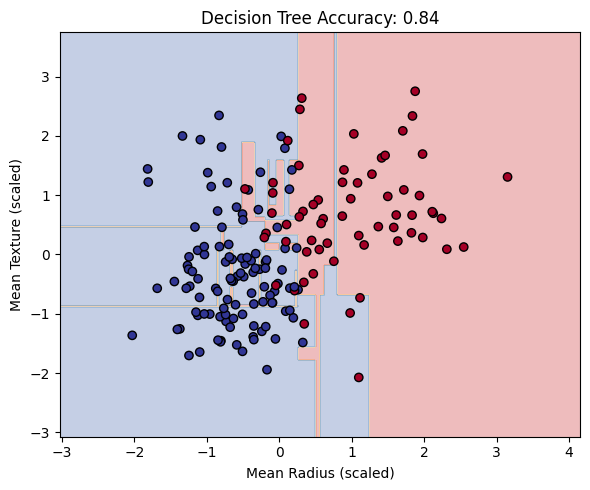

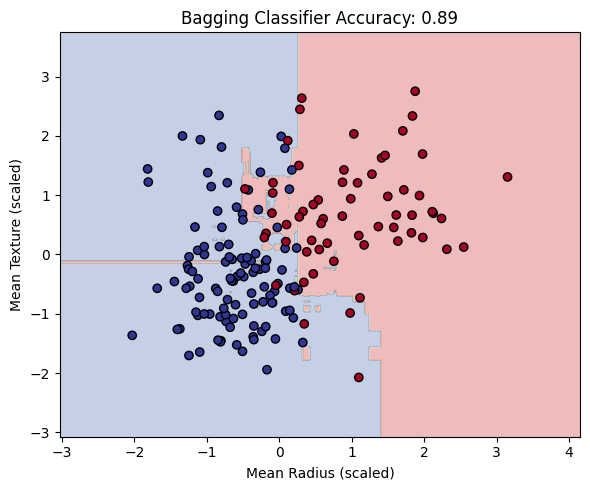

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
# Load dataset
data = load_breast_cancer()
X = data.data[:, [0, 1]]  # mean radius and mean texture
y = data.target
# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
# Train single decision tree
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_train, y_train)
acc_dt = accuracy_score(y_test, dt.predict(X_test))
# Train bagging classifier
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=0)
bag.fit(X_train, y_train)
acc_bag = accuracy_score(y_test, bag.predict(X_test))
# Plotting function
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='k')
    plt.xlabel("Mean Radius (scaled)")
    plt.ylabel("Mean Texture (scaled)")
    plt.title(title)
    plt.tight_layout()
    plt.show()
# Show plots
plot_decision_boundary(dt, X_test, y_test, f"Decision Tree Accuracy: {acc_dt:.2f}")
plot_decision_boundary(bag, X_test, y_test, f"Bagging Classifier Accuracy: {acc_bag:.2f}")